In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import zipfile
import os

zip_path = "/content/Car Data.zip"
extract_path = "/content/"

# Check if the zip file exists and extract if it does
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_path}' extracted to '{extract_path}'")
else:
    print(f"Zip file not found at '{zip_path}'. Please ensure the file is uploaded.")

# Attempt to read the CSV file after extraction
data = pd.read_csv("/content/CAR DETAILS FROM CAR DEKHO.csv")
data.head()

'/content/Car Data.zip' extracted to '/content/'


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
data.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


## Data Exploration and Preprocessing

In [5]:
# Check unique values for categorical columns
for column in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"Unique values in '{column}': {data[column].unique()}")
    print(f"Value counts in '{column}':\n{data[column].value_counts()}\n")

Unique values in 'fuel': ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
Value counts in 'fuel':
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

Unique values in 'seller_type': ['Individual' 'Dealer' 'Trustmark Dealer']
Value counts in 'seller_type':
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

Unique values in 'transmission': ['Manual' 'Automatic']
Value counts in 'transmission':
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

Unique values in 'owner': ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']
Value counts in 'owner':
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64



In [6]:
# Display descriptive statistics for numerical columns
display(data.describe())

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Average Kilometers Driven by Categorical Features

In [7]:
# Grouped summaries for 'km_driven' by categorical features
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_cols:
    print(f"\nAverage km_driven by {col}:")
    display(data.groupby(col)['km_driven'].mean().sort_values(ascending=False))


Average km_driven by fuel:


,km_driven
fuel,
LPG,89634.782609
Diesel,79630.977706
CNG,67234.750000
Electric,62000.000000
Petrol,52340.079604



Average km_driven by seller_type:


,km_driven
seller_type,
Individual,71167.556104
Dealer,52827.259557
Trustmark Dealer,39202.215686



Average km_driven by transmission:


,km_driven
transmission,
Manual,68118.162898
Automatic,49688.803571



Average km_driven by owner:


,km_driven
owner,
Third Owner,99304.506579
Fourth & Above Owner,99138.135802
Second Owner,81783.518987
First Owner,56015.009887
Test Drive Car,4155.000000


**Categorical distributions**

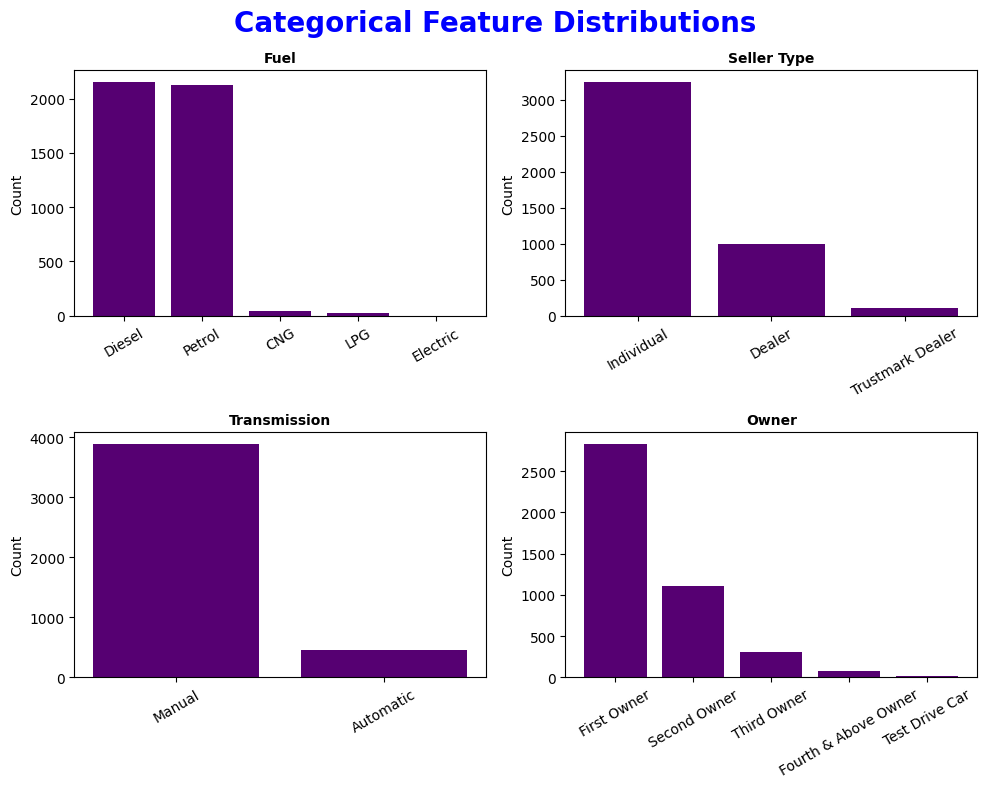

In [8]:
#categorical columns

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

fig, axes = plt.subplots(2, 2, figsize = (10,8)) # axes = (0,0), (0,1), (1,0,),(1,1)
fig.suptitle("Categorical Feature Distributions", fontsize = 20, color = "Blue", fontweight= 'bold')

for ax, col in zip(axes.flatten(), cat_cols):
  counts = data[col].value_counts()
  bars = ax.bar(counts.index, counts.values, color = '#560072')

  ax.set_title(col.replace("_", " ").title(), fontsize = 10, fontweight = "bold")
  ax.set_xlabel('')
  ax.set_ylabel('Count')
  ax.tick_params(axis = 'x', rotation = 30)


plt.tight_layout()
plt.show()

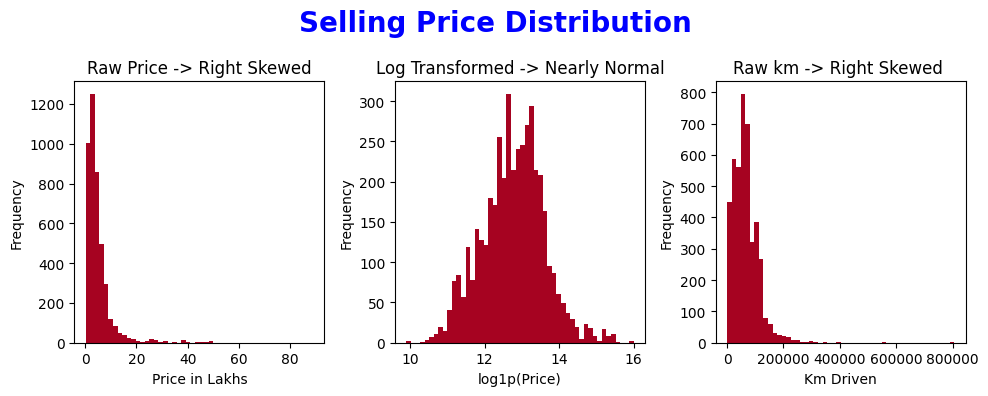

In [9]:
# target Distribution

fig , (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (10,4))
fig.suptitle("Selling Price Distribution", fontsize = 20, color = "Blue", fontweight= 'bold')

ax1.hist(data['selling_price']/1e5, bins = 50, color = '#A60321')
ax1.set_xlabel('Price in Lakhs')
ax1.set_ylabel('Frequency')
ax1.set_title("Raw Price -> Right Skewed")
# ax.tick_params(axis = 'x', rotation = 30)

ax2.hist(np.log1p(data['selling_price']), bins = 50, color = "#A60321")
ax2.set_xlabel('log1p(Price)')
ax2.set_ylabel('Frequency')
ax2.set_title("Log Transformed -> Nearly Normal")

ax3.hist(data['km_driven'], bins = 50, color = "#A60321")
ax3.set_xlabel('Km Driven')
ax3.set_ylabel('Frequency')
ax3.set_title("Raw km -> Right Skewed ")

plt.tight_layout()
plt.show()

### Numerical Feature Distributions

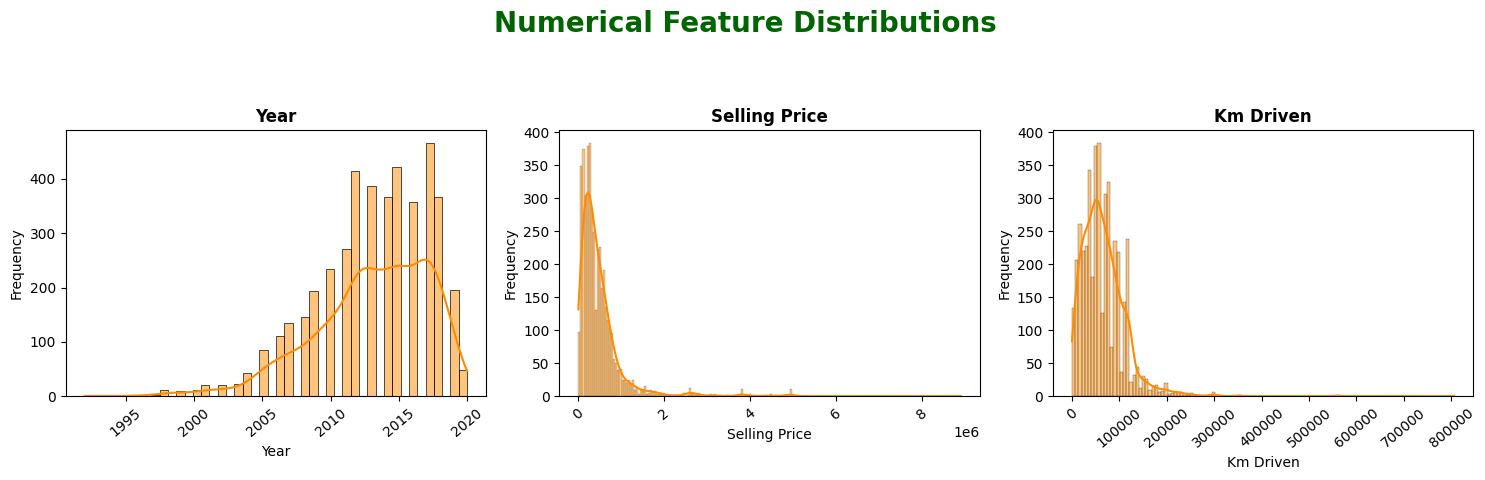

In [10]:
numerical_cols = ['year', 'selling_price', 'km_driven']

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 1 row, 3 columns for numerical features
fig.suptitle("Numerical Feature Distributions", fontsize=20, color="DarkGreen", fontweight='bold') # Matching categorical suptitle style with new color

for ax, col in zip(axes.flatten(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax, color='DarkOrange') # Using a new distinct color
    ax.set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel('Frequency')
    ax.tick_params(axis = 'x', rotation = 40)

plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()

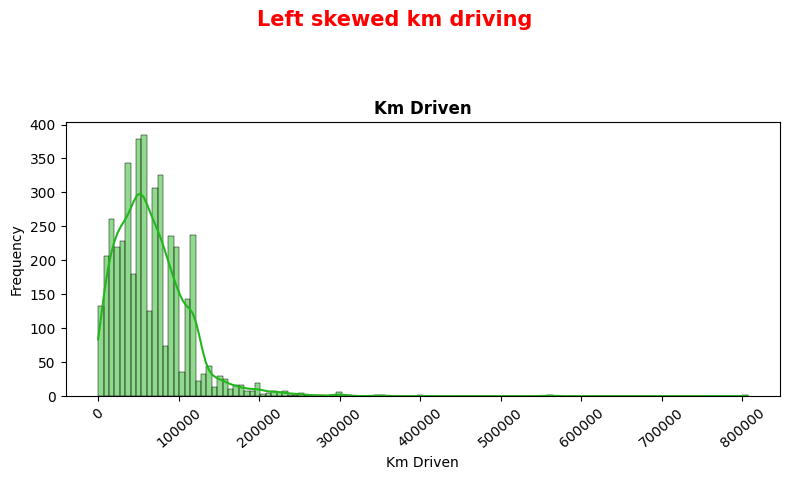

In [11]:
#Numerical Category km Driving
col = 'km_driven'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Left skewed km driving", fontsize=15, color="Red", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#22B71C')
ax.set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace("_", " ").title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

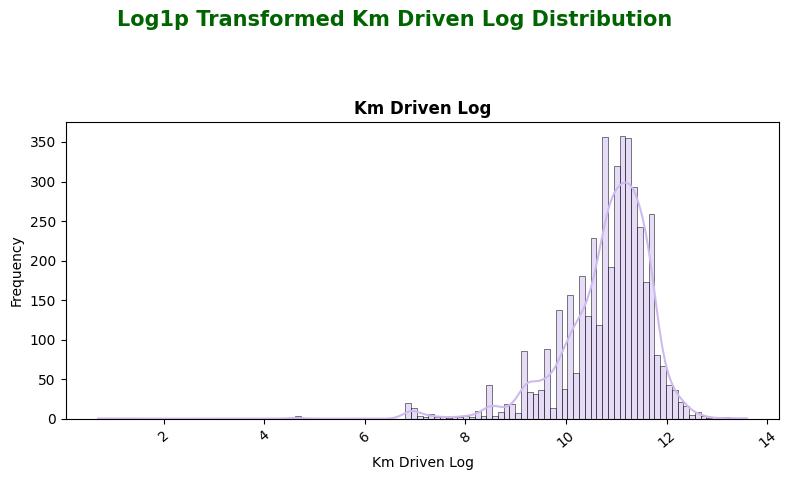

In [12]:
# Apply log1p transformation to 'km_driven'
data['km_driven_log'] = np.log1p(data['km_driven'])

# Plot the distribution of the transformed 'km_driven_log'
col = 'km_driven_log'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Log1p Transformed {col.replace('_', ' ').title()} Distribution", fontsize=15, color="DarkGreen", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#cfbaf0')
ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace('_', ' ').title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

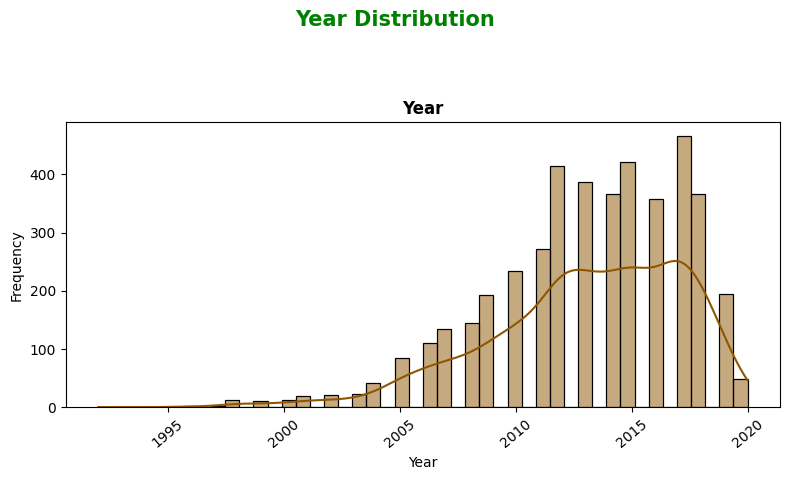

In [13]:
#Numerical Category Year Distribution
col = 'year'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f"{col.replace('_', ' ').title()} Distribution", fontsize=15, color="Green", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#8F5601')
ax.set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace("_", " ").title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

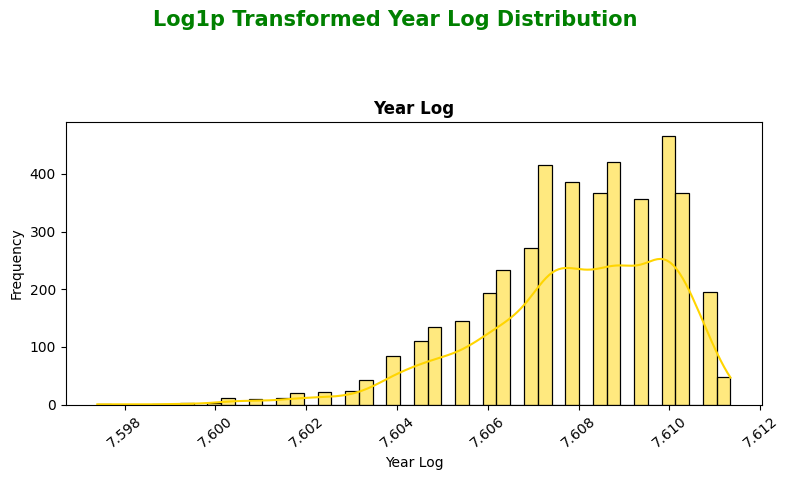

In [14]:
import numpy as np

# Apply log1p transformation to 'year'
data['year_log'] = np.log1p(data['year'])

# Plot the distribution of the transformed 'year_log'
col = 'year_log'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Log1p Transformed {col.replace('_', ' ').title()} Distribution", fontsize=15, color="Green", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#ffd500')
ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace('_', ' ').title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

Now, we will update the `X` and `y` variables to use the newly created log-transformed features for predicting 'year_log'.

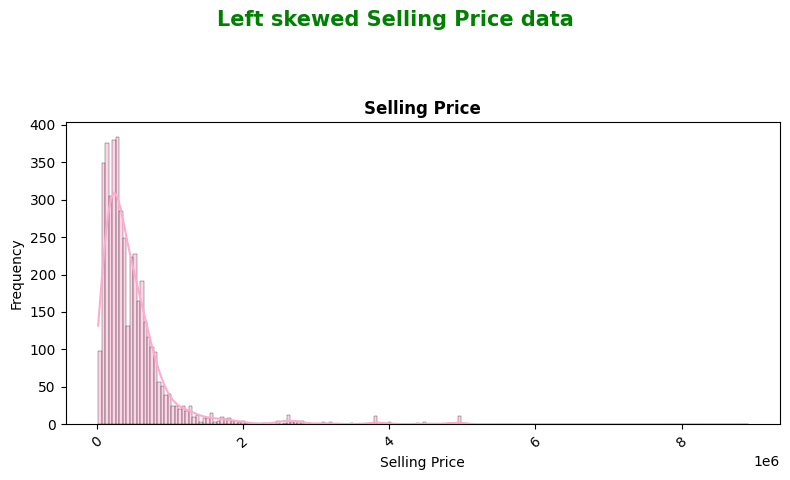

In [15]:
#Numerical Category Selling Year Distribution
col = 'selling_price'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Left skewed Selling Price data", fontsize=15, color="Green", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#FFAACF')
ax.set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace("_", " ").title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

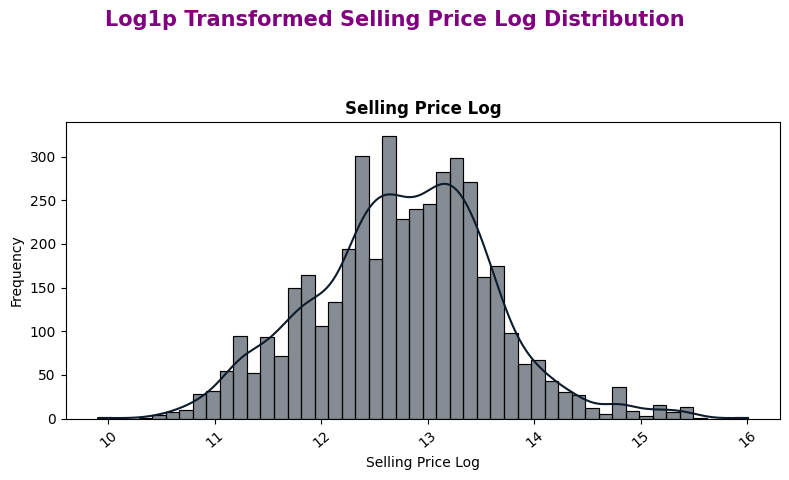

In [16]:
import numpy as np

# Apply log1p transformation to 'selling_price'
data['selling_price_log'] = np.log1p(data['selling_price'])

# Plot the distribution of the transformed 'selling_price_log'
col = 'selling_price_log'
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Log1p Transformed {col.replace('_', ' ').title()} Distribution", fontsize=15, color="Purple", fontweight='bold')
sns.histplot(data[col], kde=True, ax=ax, color='#0d1b2a')
ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight="bold")
ax.set_xlabel(col.replace('_', ' ').title())
ax.set_ylabel('Frequency')
ax.tick_params(axis = 'x', rotation = 40)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

### Feature Engineering: Car Age

In [17]:
#car_age
current_year = 2026
data['car_age'] = current_year - data['year']

### Ordinal Encoding: Fuel Type

In [18]:
# Ordinal Encoding for 'fuel' type (based on common hierarchy/frequency)
fuel_map = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
data['fuel_encoded'] = data['fuel'].map(fuel_map)


### Ordinal Encoding: Seller Type

In [19]:
# Ordinal Encoding for 'seller_type'
seller_map = {'Individual': 0, 'Dealer': 1, 'Trustmark Dealer': 2}
data['seller_type_encoded'] = data['seller_type'].map(seller_map)

### Ordinal Encoding: Transmission

In [20]:
# Ordinal Encoding for 'transmission'
transmission_map = {'Manual': 0, 'Automatic': 1}
data['transmission_encoded'] = data['transmission'].map(transmission_map)

### Ordinal Encoding: Owner Type

In [21]:
# Ordinal Encoding for 'owner'
owner_map = {
    'First Owner': 0,'Second Owner': 1,'Third Owner': 2,'Fourth & Above Owner': 3,'Test Drive Car': 4
}
data['owner_encoded'] = data['owner'].map(owner_map)



### Binning Numerical Feature: `km_driven`

In [22]:
# Encoding for 'km_driven' by binning into ordinal categories (using quantiles)
data['km_driven_category'] = pd.qcut(data['km_driven'], q=4, labels=[0, 1, 2, 3], duplicates='drop')

### Reviewing Updated DataFrame

In [23]:
# Display the first few rows with the new columns
print("DataFrame head with new encoded columns:")
display(data.head())

# Display the updated DataFrame info to see new columns and their dtypes
print("\nUpdated DataFrame Info:")
data.info()

DataFrame head with new encoded columns:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,km_driven_log,year_log,selling_price_log,car_age,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded,km_driven_category
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,11.156265,7.604894,11.002117,19,0,0,0,0,2
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,10.819798,7.604894,11.813037,19,0,0,0,0,1
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,11.512935,7.607381,13.304687,14,1,0,0,0,3
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,10.736418,7.609862,12.429220,9,0,0,0,0,1
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,11.856522,7.608374,13.017005,12,1,0,0,1,3



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   name                  4340 non-null   object  
 1   year                  4340 non-null   int64   
 2   selling_price         4340 non-null   int64   
 3   km_driven             4340 non-null   int64   
 4   fuel                  4340 non-null   object  
 5   seller_type           4340 non-null   object  
 6   transmission          4340 non-null   object  
 7   owner                 4340 non-null   object  
 8   km_driven_log         4340 non-null   float64 
 9   year_log              4340 non-null   float64 
 10  selling_price_log     4340 non-null   float64 
 11  car_age               4340 non-null   int64   
 12  fuel_encoded          4340 non-null   int64   
 13  seller_type_encoded   4340 non-null   int64   
 14  transmission_encoded  4340 non-

# Here for the X And Y for regression

**Linear Regression Variables**

Dependent Variable (Y):
The dependent variable is the value we want the model to predict.

Possible Y variables:

selling_price,km_driven,car_age,year

**These are all of the Y Numerical and Continous Categories**

Independent Variables (X):
It can be multiple variables for any across except Y Ones.

In [24]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [25]:
# 1st Category: Predict Selling Price Log (original target for residual analysis)
# Features chosen to avoid direct data leakage with the target 'selling_price_log'
X = data[['km_driven_log', 'car_age', 'fuel_encoded',
          'seller_type_encoded', 'transmission_encoded', 'owner_encoded']]
y = data['selling_price_log']

In [26]:
# 2nd Category: Predict Kilometers Driven
X = data[['selling_price', 'car_age', 'fuel_encoded',
        'seller_type_encoded', 'transmission_encoded',
        'owner_encoded']]
y = data['km_driven']

In [27]:
# 3rd Category: Predict Car Age
X = data[['selling_price', 'km_driven', 'fuel_encoded',
        'seller_type_encoded', 'transmission_encoded',
        'owner_encoded']]
y = data['car_age']

In [28]:
#4th Category: Predict Year (using log-transformed features) -- NOTE: This was previously used for data leakage demonstration. Keep for reference.
X = data[['selling_price_log', 'km_driven_log', 'car_age', 'fuel_encoded',
        'seller_type_encoded', 'transmission_encoded',
        'owner_encoded']]
y = data['year_log'] # Use the log-transformed year

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3472, 7)
X_test shape: (868, 7)
y_train shape: (3472,)
y_test shape: (868,)


In [30]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Data scaled successfully!
X_train_scaled shape: (3472, 7)
X_test_scaled shape: (868, 7)


In [31]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("\ny data scaled successfully!")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")


y data scaled successfully!
y_train_scaled shape: (3472, 1)
y_test_scaled shape: (868, 1)


**Model Training**

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

In [34]:
data.shape

(4340, 17)

In [35]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

print("Model trained successfully for selling_price_log prediction!")

Model trained successfully for selling_price_log prediction!


## Residual Analysis

Residual analysis is crucial for checking the assumptions of a linear regression model. We examine the residuals (the difference between actual and predicted values) to identify any patterns, non-linearity, or heteroscedasticity. Ideally, residuals should be randomly distributed around zero, with no discernible patterns.

## Overfitting vs. Data Leakage (Revisiting the 99% R2 Score)

### Overfitting
Overfitting occurs when a model learns the training data *too well*, including noise and specific patterns that are not representative of the underlying relationship. An overfit model performs exceptionally well on the training data but fails to generalize to new, unseen data.

**Characteristics of Overfitting:**
*   Very high performance (e.g., R2 score) on training data.
*   Significantly lower performance on test or validation data.
*   Often happens with overly complex models or insufficient training data.

### Data Leakage
Data leakage is a more subtle and insidious problem where information from the target variable (or the test set) unintentionally "leaks" into the training process. This makes the model appear to perform very well, but the performance is misleading because it's based on information that wouldn't be available in a real-world prediction scenario.

**Why the 99% R2 Score was Data Leakage:**
In our previous model where we were predicting `year_log` (log-transformed car year) and achieved a 99% R2 score, the primary reason was **data leakage** through the `car_age` feature.

*   **`car_age` Definition:** `car_age` was calculated as `current_year - data['year']`.
*   **`year_log` Definition:** `year_log` was `np.log1p(data['year'])`.

Since `car_age` is *directly derived from `year`* (the untransformed version of `year_log`), the model was essentially being asked to predict a transformation of `year` using a feature (`car_age`) that contained nearly direct information about `year`. This created an almost perfect linear relationship between a feature and the target, allowing the model to make highly accurate (but uninformative for real prediction) predictions. The model wasn't 'learning' from independent signals; it was effectively being given the answer in a slightly disguised form.

This is not typical overfitting where the model learns noise. Instead, it's a structural flaw in the feature engineering and problem definition that provides an unfair advantage to the model, leading to an inflated and unrealistic performance metric.

## Resolving Data Leakage: Predicting Selling Price Log

To address the data leakage issue, we will revert to predicting `selling_price_log` using features that are less directly correlated with the target and do not provide prior information. The features for prediction will be `km_driven_log`, `car_age`, and the encoded categorical features.

In [41]:
# Redefine X and y to predict 'selling_price_log' without data leakage
X = data[['km_driven_log', 'car_age', 'fuel_encoded',
          'seller_type_encoded', 'transmission_encoded', 'owner_encoded']]
y = data['selling_price_log']

print("X and y redefined for predicting selling_price_log.")

X and y redefined for predicting selling_price_log.


In [42]:
# Re-split the data into training and testing sets with the updated X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3472, 6)
X_test shape: (868, 6)
y_train shape: (3472,)
y_test shape: (868,)


In [43]:
# Re-scale numerical features of X
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX data scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


X data scaled successfully!
X_train_scaled shape: (3472, 6)
X_test_scaled shape: (868, 6)


In [44]:
# Re-scale the target variable y
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("\ny data scaled successfully!")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")


y data scaled successfully!
y_train_scaled shape: (3472, 1)
y_test_scaled shape: (868, 1)


### Retraining the Model and Re-evaluating Performance

Now, let's retrain the `LinearRegression` model with the corrected `X` and `y`, and evaluate its performance again.

In [45]:
# Train a new Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train_scaled, y_train_scaled)

print("Model trained successfully for selling_price_log prediction with corrected features!")

Model trained successfully for selling_price_log prediction with corrected features!


In [50]:
# Make predictions on the scaled test set using the new model
y_pred_new_scaled = model_new.predict(X_test_scaled)

# Calculate MSE and R2 score for the new model
mse_new = mean_squared_error(y_test_scaled, y_pred_new_scaled)
r2_new = r2_score(y_test_scaled, y_pred_new_scaled)

print(f"\nMean Squared Error (New Model - Predicting selling_price_log): {mse_new:.4f}")
print(f"R2 Score (New Model - Predicting selling_price_log): {r2_new:.4f}")


Mean Squared Error (New Model - Predicting selling_price_log): 0.3504
R2 Score (New Model - Predicting selling_price_log): 0.6404


### New Residual Analysis

Let's re-examine the residuals and actual vs. predicted plots with the updated model.

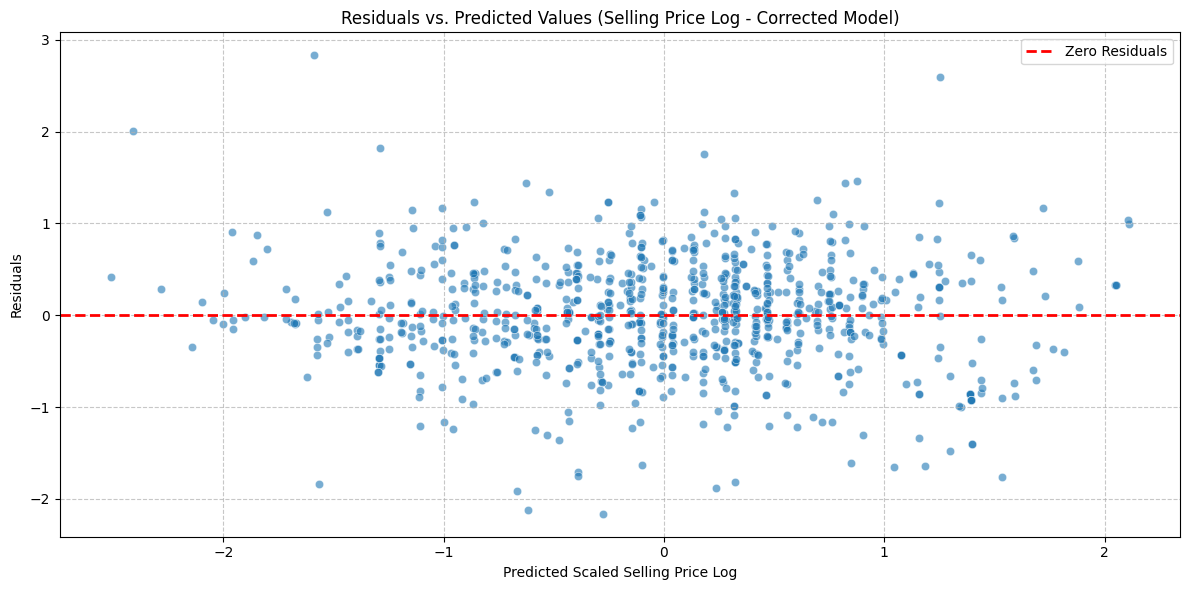

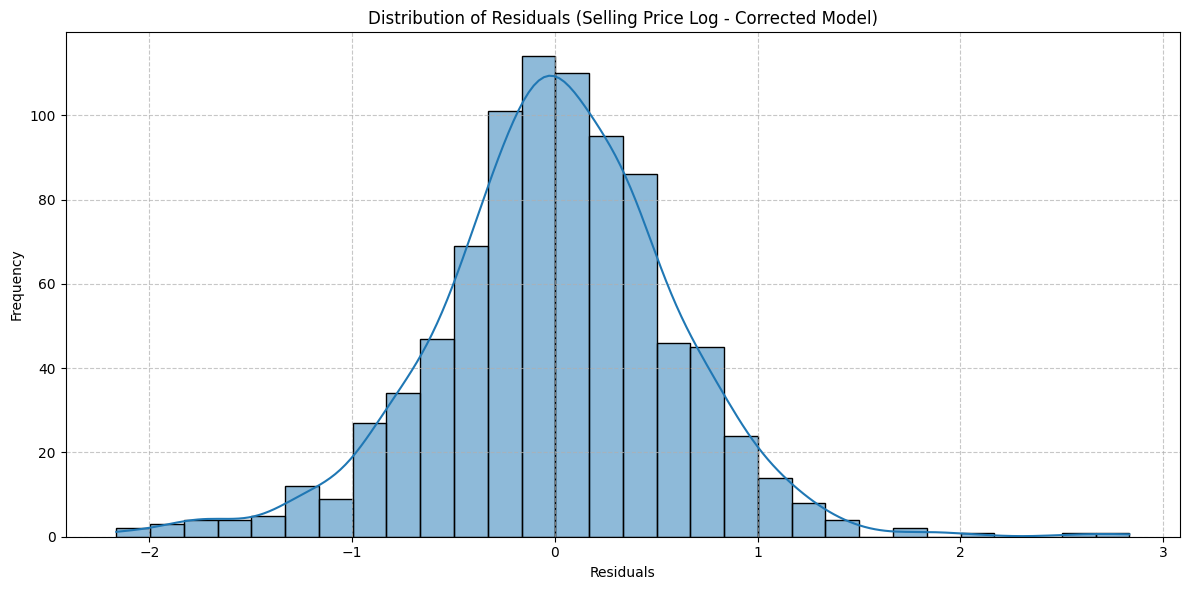

In [47]:
# Calculate residuals for the new model
residuals_new = y_test_scaled - y_pred_new_scaled

# Plotting residuals vs. predicted values for the new model
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred_new_scaled.flatten(), y=residuals_new.flatten(), alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residuals')
plt.title('Residuals vs. Predicted Values (Selling Price Log - Corrected Model)')
plt.xlabel('Predicted Scaled Selling Price Log')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting the distribution of residuals for the new model
plt.figure(figsize=(12, 6))
sns.histplot(residuals_new.flatten(), kde=True, bins=30)
plt.title('Distribution of Residuals (Selling Price Log - Corrected Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

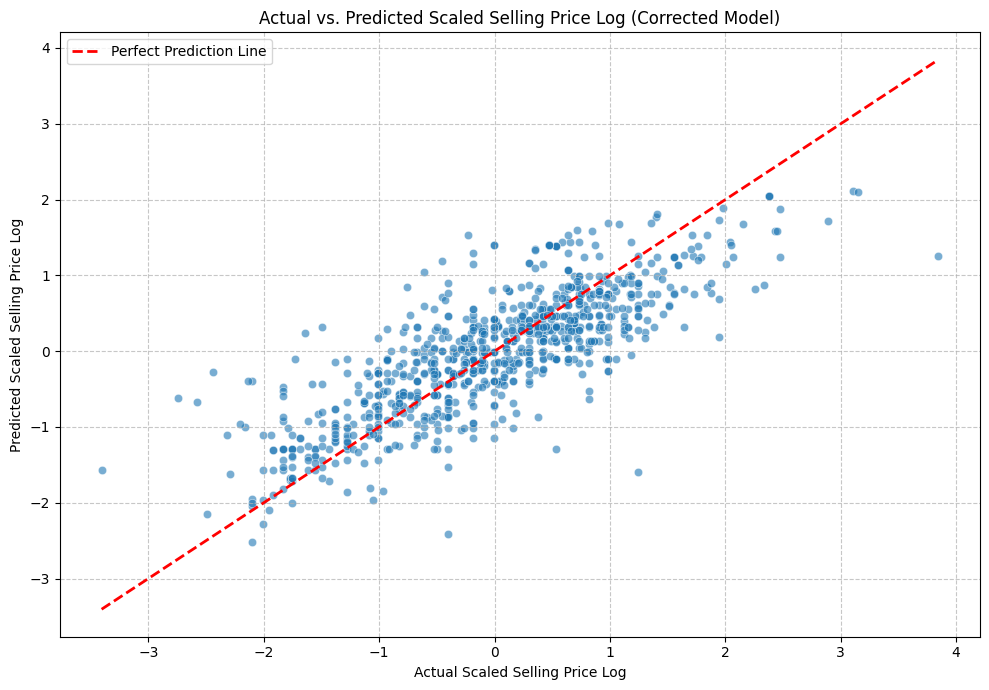

In [48]:
# Plotting Actual vs. Predicted Values for selling_price_log (New Model)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_scaled.flatten(), y=y_pred_new_scaled.flatten(), alpha=0.6)
plt.plot([min(y_test_scaled), max(y_test_scaled)], [min(y_test_scaled), max(y_test_scaled)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Scaled Selling Price Log (Corrected Model)')
plt.xlabel('Actual Scaled Selling Price Log')
plt.ylabel('Predicted Scaled Selling Price Log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()